# Training and Inference Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import mlx.core as mx
from modules import build_vocab, GPT

## Training History Analysis

In [2]:
df = pd.read_csv("history.csv")
df.tail()

,step,train_loss,val_loss,ppl
44,9000,0.9691,1.5591,4.75
45,9200,0.9652,1.5563,4.74
46,9400,0.9609,1.5737,4.82
47,9600,0.9569,1.5646,4.78
48,9800,0.9524,1.5766,4.84


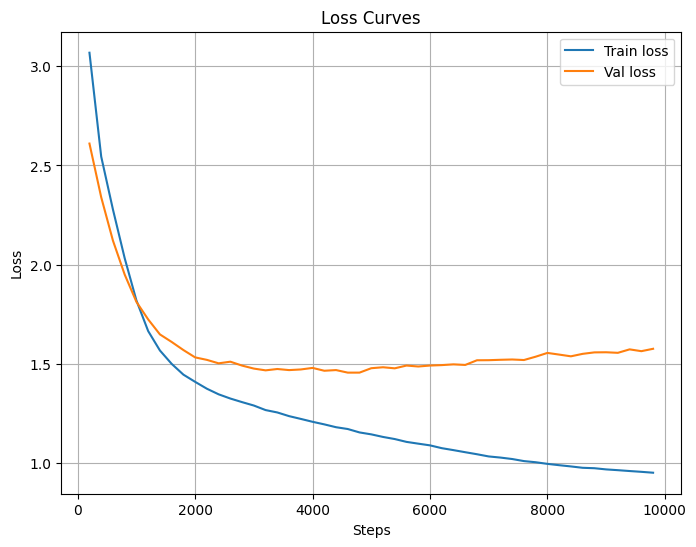

In [3]:
plt.figure(figsize=(8, 6))
plt.plot(df["step"], df["train_loss"], label="Train loss")
plt.plot(df["step"], df["val_loss"], label="Val loss")
plt.title("Loss Curves")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

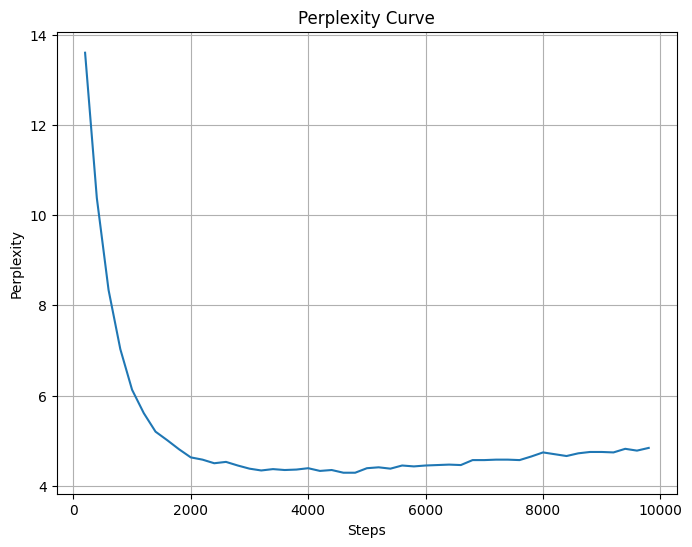

In [4]:
plt.figure(figsize=(8, 6))
plt.plot(df["step"], df["ppl"])
plt.title("Perplexity Curve")
plt.xlabel("Steps")
plt.ylabel("Perplexity")
plt.grid(True)
plt.show()

## Inference

In [5]:
mx.random.seed(42)

with open("dataset.txt", "r", encoding="utf-8") as f:
    data = f.read()

vocab_size, encode, decode = build_vocab(data)

model = GPT(vocab_size, seq_len=256, d_model=384, num_heads=6, n_layers=6)
model.load_weights("best_model.npz")

prompts = [
    "Messenger: Where's Caius Marcius?",
    "HAMLET: To be, or not to be",
    "JULIET: O Romeo, my",
    "ROMEO: Docker is",
]

In [6]:
for i, prompt in enumerate(prompts, start=1):
    print(f"[{i}: {prompt}]")
    for token in model.generate(
        prompt,
        encode,
        decode,
        max_len=100,
        temperature=0.3,
    ):
        print(token, end="", flush=True)
    print("\n")

[1: Messenger: Where's Caius Marcius?]


COMINIUS:
The words shall be spoke a cause.

CORIOLANUS:
What are the shore?

MENENIUS:
What say's

[2: HAMLET: To be, or not to be]
 the princely
To me the witness of my son, and the war
Of my father is a fortune's tongues of the ba

[3: JULIET: O Romeo, my]
 gracious lord,
And there is the seat of the court of the state,
Whose heavens and the seal of the w

[4: ROMEO: Docker is]
 the best of a strange of the life,
Who shall not be satisfied the prince,
Who shall not be such a d



In [7]:
for i, prompt in enumerate(prompts, start=1):
    print(f"[{i}: {prompt}]")
    for token in model.generate(
        prompt,
        encode,
        decode,
        max_len=100,
        temperature=0.7,
    ):
        print(token, end="", flush=True)
    print("\n")

[1: Messenger: Where's Caius Marcius?]


CLAUDIO:
Veronae, where is not?

POLIXENES:
O, the gods morselves are the king and good
as the way

[2: HAMLET: To be, or not to be]
 spited to back'd him.
If I be turn to him so report, I have not
Than the time whereon I would he ha

[3: JULIET: O Romeo, my]
 heart!
My boy, is it but a man as a father to dischance.
Thoughts hang the air morning strong here;

[4: ROMEO: Docker is]
 dead?

BENVOLIO:
As you are a dispersed nor nor any boot,
That is come of my foiler and grave him h



In [8]:
for i, prompt in enumerate(prompts, start=1):
    print(f"[{i}: {prompt}]")
    for token in model.generate(
        prompt,
        encode,
        decode,
        max_len=100,
        temperature=1.0,
    ):
        print(token, end="", flush=True)
    print("\n")

[1: Messenger: Where's Caius Marcius?]


AUFIDIUS:
A mind bear, a thousand thing oratory
From himself, nor nice are not for the people
Of t

[2: HAMLET: To be, or not to be]
 returned, guilty
And dream on either to a sority stay;
And now are almost senses to this lost sland

[3: JULIET: O Romeo, my]
 gracious,
They are meeting men's,
How that is they set attempt me with : I part
Have here! we known

[4: ROMEO: Docker is]
 true, my lord,
In prayer many of my desertines, by the sways!

MERCUTIO:
By where should I sle I br

